In [1]:
import cv2
import os
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import numpy as np
from models.utils.data import load_groundtruths

from models import utils
from run_evaluation_summary import Model

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
experiment_root = "experiments"
trained_model_root = "trained_model"
model_name = "stilted_snowball"
model_tag = "best_map"
optimized_cpu_inference = True

In [3]:
cfg = utils.load_model_yaml(model_name, experiment_root)
model_path = utils.find_model_pth_paths(trained_model_root, model_name, model_tag)
cfg.model.metadata.best_model_folder = os.path.dirname(model_path[0])
if OmegaConf.select(cfg, "model.attention_type") is not None:
    attention_type = cfg.model.attention_type
    print("attention_type:", attention_type)
else:
    print("attention_type does not exist")
    cfg.model.attention_type = None
inference_model_name = os.path.splitext(os.path.basename(model_path[0]))[0]
model = Model(cfg, model_name=inference_model_name, optimized_cpu_inference=optimized_cpu_inference)

attention_type: ResidualCBAM


/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Freezing conv1.weight
Freezing bn1.weight
Freezing bn1.bias
Freezing layer1.0.conv1.weight
Freezing layer1.0.bn1.weight
Freezing layer1.0.bn1.bias
Freezing layer1.0.conv2.weight
Freezing layer1.0.bn2.weight
Freezing layer1.0.bn2.bias
Freezing layer1.0.conv3.weight
Freezing layer1.0.bn3.weight
Freezing layer1.0.bn3.bias
Freezing layer1.0.downsample.0.weight
Freezing layer1.0.downsample.1.weight
Freezing layer1.0.downsample.1.bias
Freezing layer1.1.conv1.weight
Freezing layer1.1.bn1.weight
Freezing layer1.1.bn1.bias
Freezing layer1.1.conv2.weight
Freezing layer1.1.bn2.weight
Freezing layer1.1.bn2.bias
Freezing layer1.1.conv3.weight
Freezing layer1.1.bn3.weight
Freezing layer1.1.bn3.bias
Freezing layer1.2.conv1.weight
Freezing layer1.2.bn1.weight
Freezing layer1.2.bn1.bias
Freezing layer1.2.conv2.weight
Freezing layer1.2.bn2.weight
Freezing layer1.2.bn2.bias
Freezing layer1.2.conv3.weight
Freezing layer1.2.bn3.weight
Freezing layer1.2.bn3.bias
Freezing fc.weight
Freezing fc.bias


In [4]:
image_paths, boxes, labels, num_samples = load_groundtruths(cfg.dataset.val.replace('..', 'dataset'), train=False, shuffle=False, debug=False)

Total 386 images and 386 boxes loaded from: dataset/Dataset/validation/Vehicle registration plate


In [5]:
nms_threshold = 0.4
score_threshold = 0.75
iterator = iter(range(num_samples))

In [6]:
def add_gt_boxes(image, boxes, color=(0, 255, 0), thickness=-1):
    for idx, box in enumerate(boxes):
        xmin = box[0]
        ymin = box[1]
        xmax = box[2]
        ymax = box[3]
        image = cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness)
    return image

def plot(prediction, true_boxes):
    # Define subplots
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(10, 10),
    )
    # Plot Predictions.
    orig_image = utils.draw_bbox(
        prediction['image_array'],
        np.array(prediction['final_boxes'], dtype=np.int32),
        labels=pred['class_names'],
        color=(255, 0, 0),
        thickness=2,
    )

    orig_image = add_gt_boxes(orig_image, true_boxes, color=(0, 255, 0), thickness=2)

    ax.imshow(orig_image)
    ax.axis("off")

    plt.figtext(0.50, 0.9, "Predictions", fontsize=20, color="r", ha="center")

    plt.show(block=False)

    return fig

3
dataset/Dataset/validation/Vehicle registration plate/0170ea8e1a33375a.jpg


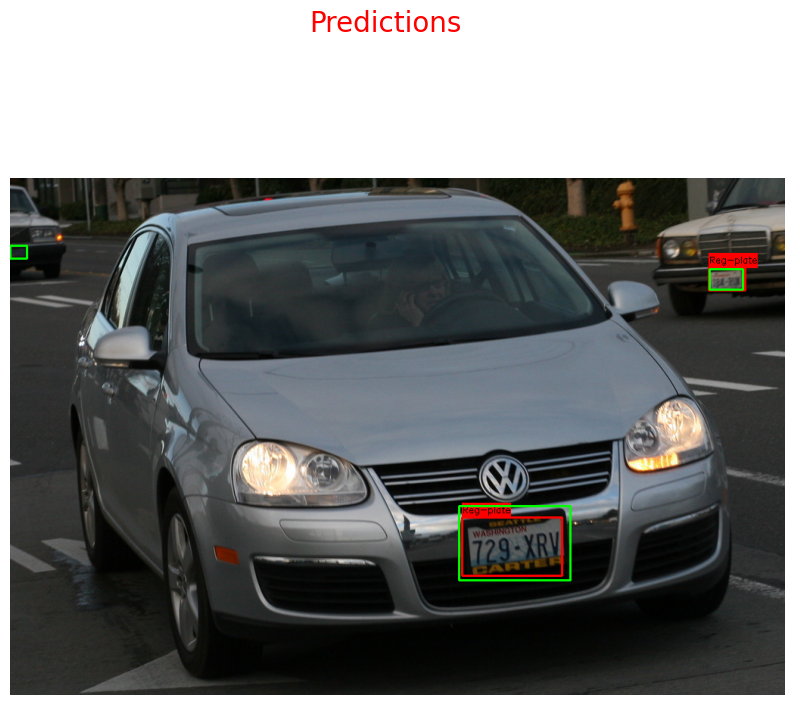

In [14]:
idx = next(iterator)
print(idx)
print(image_paths[idx])
pred = model(image_paths[idx], nms_threshold=nms_threshold, score_threshold=score_threshold)
true_boxes = np.array(boxes[idx], dtype=np.int32)
figure = plot(pred, true_boxes)

In [15]:
import torch
from models.src.encoder import YOLODataEncoder
from models.src.yolo import YOLO

input_size = cfg.model.image_size[:2]

image = cv2.imread(image_paths[idx])
img_size = image.shape
bboxes = boxes[idx]
bboxes_resized = torch.tensor(bboxes, dtype=torch.float)
bboxes_resized[:, [0, 2]] *= (input_size[1] / img_size[1])
bboxes_resized[:, [1, 3]] *= (input_size[0] / img_size[0])
image = cv2.resize(image, input_size)
image_tensor = torch.tensor(image, dtype=torch.float).permute(2, 0, 1).unsqueeze(0)
test_model = YOLO(backbone_name=cfg.model.backbone_name,
                     train_backbone=cfg.model.train_backbone,
                     returned_layers=cfg.model.returned_layers,
                     num_classes=cfg.dataset.nc,
                     fpn_channels=cfg.model.fpn_channels,
                     attention_type=cfg.model.attention_type,)
data_encoder = YOLODataEncoder(input_size=cfg.model.image_size[:2],
                               classes=cfg.dataset.names,
                               strides=test_model.backbone.strides,
                               top_k_per_level=cfg.model.top_k_per_level,
                               center_radius=cfg.model.center_radius,
                               allow_multi_level=cfg.model.allow_multi_level,
                               debug=cfg.experiment.train.debug,
                                       )
label_array = torch.tensor(labels[idx], dtype=torch.int64) - 1
encoded = data_encoder.encode(bboxes_resized, label_array)

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Freezing conv1.weight
Freezing bn1.weight
Freezing bn1.bias
Freezing layer1.0.conv1.weight
Freezing layer1.0.bn1.weight
Freezing layer1.0.bn1.bias
Freezing layer1.0.conv2.weight
Freezing layer1.0.bn2.weight
Freezing layer1.0.bn2.bias
Freezing layer1.0.conv3.weight
Freezing layer1.0.bn3.weight
Freezing layer1.0.bn3.bias
Freezing layer1.0.downsample.0.weight
Freezing layer1.0.downsample.1.weight
Freezing layer1.0.downsample.1.bias
Freezing layer1.1.conv1.weight
Freezing layer1.1.bn1.weight
Freezing layer1.1.bn1.bias
Freezing layer1.1.conv2.weight
Freezing layer1.1.bn2.weight
Freezing layer1.1.bn2.bias
Freezing layer1.1.conv3.weight
Freezing layer1.1.bn3.weight
Freezing layer1.1.bn3.bias
Freezing layer1.2.conv1.weight
Freezing layer1.2.bn1.weight
Freezing layer1.2.bn1.bias
Freezing layer1.2.conv2.weight
Freezing layer1.2.bn2.weight
Freezing layer1.2.bn2.bias
Freezing layer1.2.conv3.weight
Freezing layer1.2.bn3.weight
Freezing layer1.2.bn3.bias
Freezing fc.weight
Freezing fc.bias


In [16]:
num_classes = cfg.dataset.nc

target_obj = encoded[:, 0]
pos_mask = target_obj > 0.5

fake_obj_logits = torch.full_like(target_obj, -20.0)
fake_obj_logits[pos_mask] = 20.0

fake_bbox = encoded[:, 1:5].clone()

fake_class_logits = torch.full(
    (encoded.shape[0], num_classes),
    -20.0,
    device=encoded.device,
    dtype=encoded.dtype,
)
fake_class_logits[pos_mask, 0] = 20.0

fake_logits = torch.cat(
    [
        fake_obj_logits[:, None],
        fake_bbox,
        fake_class_logits,
    ],
    dim=1,
)

decoded = data_encoder.decode(fake_logits)
decoded[:, [0, 2]] /= (input_size[1] / img_size[1])
decoded[:, [1, 3]] /= (input_size[0] / img_size[0])
decoded

tensor([[  0.0000,  89.3152,  22.1051, 106.1020,   1.0000,   0.0000],
        [924.7180, 120.3064, 968.5586, 147.4235,   1.0000,   0.0000],
        [593.9896, 433.9393, 740.3387, 531.4792,   1.0000,   0.0000]])

In [17]:
boxes[idx]

[[0.0, 89.315227, 22.105088000000002, 106.10200100000002],
 [593.989632, 433.93926899999997, 740.3386879999999, 531.479182],
 [924.7180800000001, 120.30635199999999, 968.558592, 147.423501]]

In [20]:
pos_idx = torch.where(encoded[:, 0] > 0.5)[0]

pos_encoded = encoded[pos_idx]
pos_centers = data_encoder.grid_centers[pos_idx].to(encoded.device)

debug_rows = []

for i, row_idx in enumerate(pos_idx):
    obj, dx, dy, dw, dh, cls = pos_encoded[i]
    cell_x, cell_y, grid_h, grid_w, stride = pos_centers[i]

    # Decode this encoded row back to xyxy
    cx = cell_x + dx * stride
    cy = cell_y + dy * stride
    w = torch.exp(dw) * stride
    h = torch.exp(dh) * stride

    decoded_box = torch.tensor([
        cx - 0.5 * w,
        cy - 0.5 * h,
        cx + 0.5 * w,
        cy + 0.5 * h,
    ], device=encoded.device)

    debug_rows.append({
        "row_idx": int(row_idx.item()),
        "stride": int(stride.item()),
        "cell_x": float(cell_x.item()),
        "cell_y": float(cell_y.item()),
        "dx": float(dx.item()),
        "dy": float(dy.item()),
        "dw": float(dw.item()),
        "dh": float(dh.item()),
        "decoded_box": decoded_box.detach().cpu().tolist(),
    })

def box_iou_xyxy(a, b):
    a = torch.as_tensor(a, dtype=torch.float32)
    b = torch.as_tensor(b, dtype=torch.float32)

    lt = torch.maximum(a[:, None, :2], b[None, :, :2])
    rb = torch.minimum(a[:, None, 2:], b[None, :, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]

    area_a = ((a[:, 2] - a[:, 0]).clamp(min=0) *
              (a[:, 3] - a[:, 1]).clamp(min=0))
    area_b = ((b[:, 2] - b[:, 0]).clamp(min=0) *
              (b[:, 3] - b[:, 1]).clamp(min=0))

    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp_min(1e-6)


pos_idx = torch.where(encoded[:, 0] > 0.5)[0]
pos_encoded = encoded[pos_idx]
pos_centers = data_encoder.grid_centers[pos_idx].to(encoded.device)

decoded_boxes = []

for i in range(pos_encoded.shape[0]):
    _, dx, dy, dw, dh, _ = pos_encoded[i]
    cell_x, cell_y, _, _, stride = pos_centers[i]

    cx = cell_x + dx * stride
    cy = cell_y + dy * stride
    w = torch.exp(dw) * stride
    h = torch.exp(dh) * stride

    decoded_boxes.append([
        cx - 0.5 * w,
        cy - 0.5 * h,
        cx + 0.5 * w,
        cy + 0.5 * h,
    ])

decoded_boxes = torch.tensor(decoded_boxes, dtype=torch.float32)
gt_boxes = bboxes_resized.detach().cpu().float()

ious = box_iou_xyxy(decoded_boxes, gt_boxes)
best_iou, gt_match = ious.max(dim=1)

for i, row_idx in enumerate(pos_idx):
    stride = int(pos_centers[i, 4].item())
    print(
        f"row={int(row_idx):5d} "
        f"stride={stride:2d} "
        f"gt={int(gt_match[i])} "
        f"iou={float(best_iou[i]):.4f} "
        f"decoded={decoded_boxes[i].tolist()}"
    )

row= 3521 stride= 4 gt=0 iou=1.0000 decoded=[0.0, 83.6921615600586, 13.815679550170898, 99.42208099365234]
row= 3681 stride= 4 gt=0 iou=1.0000 decoded=[0.0, 83.6921615600586, 13.815679550170898, 99.42208099365234]
row= 5107 stride= 4 gt=2 iou=1.0000 decoded=[577.94873046875, 112.73216247558594, 605.34912109375, 138.14208984375]
row= 5108 stride= 4 gt=2 iou=1.0000 decoded=[577.94873046875, 112.73216247558594, 605.34912109375, 138.14208984375]
row=26480 stride= 8 gt=0 iou=1.0000 decoded=[0.0, 83.6921615600586, 13.815679550170898, 99.42208099365234]
row=26481 stride= 8 gt=0 iou=1.0000 decoded=[0.0, 83.6921615600586, 13.815679550170898, 99.42208099365234]
row=26873 stride= 8 gt=2 iou=1.0000 decoded=[577.94873046875, 112.73216247558594, 605.34912109375, 138.14208984375]
row=26874 stride= 8 gt=2 iou=1.0000 decoded=[577.94873046875, 112.73216247558594, 605.34912109375, 138.14208984375]
row=33145 stride=16 gt=1 iou=1.0000 decoded=[371.2435302734375, 406.6195373535156, 462.711669921875, 498.018